<a href="https://www.kaggle.com/code/sonawanelalitsunil/stock-market-trends-august-2025-ml-84-17?scriptVersionId=255126014" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/stock-market-prediction-for-july-2025-dataset/stock_data_july_2025.csv


## Title:
Stock Market Trends – August 2025

## Description:
This dataset provides comprehensive stock market data for August 2025, including daily opening, closing, highest, and lowest prices, along with trading volumes and percentage changes for major companies and indices. It enables detailed analysis of market trends, price volatility, sector performance, and investor sentiment during the month. The data can be used for forecasting, technical analysis, portfolio evaluation, and studying the impact of global economic events on stock performance.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/stock-market-prediction-for-july-2025-dataset/stock_data_july_2025.csv')

In [3]:
df.head()

,Date,Ticker,Open Price,Close Price,High Price,Low Price,Volume Traded,Market Cap,PE Ratio,Dividend Yield,EPS,52 Week High,52 Week Low,Sector
0,2025-06-01,AAPL,185.96,187.79,188.85,183.74,42257183,2.931356e+12,28.37,0.49,6.62,248.20,155.68,Technology
1,2025-06-01,ABBV,189.63,193.64,194.31,188.03,33074970,3.289227e+11,16.74,3.51,11.57,210.83,127.91,Healthcare
2,2025-06-01,ABT,118.79,120.08,120.53,118.01,17130934,2.001333e+11,19.39,1.84,6.19,140.79,99.26,Healthcare
3,2025-06-01,ADBE,584.51,567.78,587.97,561.25,11080360,2.460380e+11,43.29,0.00,13.12,727.11,407.82,Technology
4,2025-06-01,ADP,253.46,255.60,258.59,249.91,10319559,1.052471e+11,29.92,2.04,8.54,303.75,234.28,Financials


In [4]:
df.tail()

,Date,Ticker,Open Price,Close Price,High Price,Low Price,Volume Traded,Market Cap,PE Ratio,Dividend Yield,EPS,52 Week High,52 Week Low,Sector
4341,2025-07-23,VRTX,478.20,489.78,491.84,476.65,7141573,1.275469e+11,28.64,0.00,17.10,603.57,411.70,Healthcare
4342,2025-07-23,VZ,46.61,47.75,48.26,46.15,9865947,1.856944e+11,9.31,5.82,5.13,53.28,40.22,Communication Services
4343,2025-07-23,WMT,71.65,70.99,72.35,70.46,22059711,5.560056e+11,25.93,1.27,2.74,90.05,62.53,Consumer Staples
4344,2025-07-23,XOM,117.02,112.37,118.45,111.41,13557718,4.403069e+11,15.72,3.09,7.15,122.66,100.50,Energy
4345,2025-07-23,ZTS,146.81,148.32,150.25,145.16,5102989,6.723840e+10,29.39,0.74,5.05,184.27,110.21,Healthcare


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4346 entries, 0 to 4345
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            4346 non-null   object 
 1   Ticker          4346 non-null   object 
 2   Open Price      4346 non-null   float64
 3   Close Price     4346 non-null   float64
 4   High Price      4346 non-null   float64
 5   Low Price       4346 non-null   float64
 6   Volume Traded   4346 non-null   int64  
 7   Market Cap      4346 non-null   float64
 8   PE Ratio        4346 non-null   float64
 9   Dividend Yield  4346 non-null   float64
 10  EPS             4346 non-null   float64
 11  52 Week High    4346 non-null   float64
 12  52 Week Low     4346 non-null   float64
 13  Sector          4346 non-null   object 
dtypes: float64(10), int64(1), object(3)
memory usage: 475.5+ KB


In [6]:
df.describe()

,Open Price,Close Price,High Price,Low Price,Volume Traded,Market Cap,PE Ratio,Dividend Yield,EPS,52 Week High,52 Week Low
count,4346.000000,4346.000000,4346.000000,4346.000000,4.346000e+03,4.346000e+03,4346.000000,4346.000000,4346.000000,4346.000000,4346.000000
mean,337.837002,337.907635,343.086233,332.737186,1.658002e+07,4.027126e+11,25.581173,1.807835,13.693049,410.097975,266.144823
std,472.650926,472.769476,479.915872,465.653353,1.522197e+07,6.202114e+11,12.923249,1.557671,20.268110,575.709969,377.470429
min,19.040000,18.990000,19.410000,18.900000,2.003906e+06,6.469973e+10,6.850000,0.000000,1.560000,21.130000,13.670000
25%,110.797500,110.527500,112.187500,109.292500,7.491280e+06,1.313524e+11,16.820000,0.470000,5.140000,130.547500,83.862500
50%,196.925000,195.915000,199.960000,193.745000,1.187239e+07,1.738019e+11,22.900000,1.800000,8.470000,235.125000,152.095000
75%,448.885000,451.100000,457.435000,443.027500,2.087384e+07,3.714750e+11,30.307500,2.767500,14.265000,531.735000,338.062500
max,3848.170000,3894.270000,3923.200000,3810.020000,8.996302e+07,3.589151e+12,97.700000,7.760000,197.370000,5069.750000,3529.240000


In [7]:
df.isnull().sum()

Date              0
Ticker            0
Open Price        0
Close Price       0
High Price        0
Low Price         0
Volume Traded     0
Market Cap        0
PE Ratio          0
Dividend Yield    0
EPS               0
52 Week High      0
52 Week Low       0
Sector            0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(4346, 14)

In [10]:
df.dtypes

Date               object
Ticker             object
Open Price        float64
Close Price       float64
High Price        float64
Low Price         float64
Volume Traded       int64
Market Cap        float64
PE Ratio          float64
Dividend Yield    float64
EPS               float64
52 Week High      float64
52 Week Low       float64
Sector             object
dtype: object

In [11]:
df.columns

Index(['Date', 'Ticker', 'Open Price', 'Close Price', 'High Price',
       'Low Price', 'Volume Traded', 'Market Cap', 'PE Ratio',
       'Dividend Yield', 'EPS', '52 Week High', '52 Week Low', 'Sector'],
      dtype='object')

## Data Visualizations

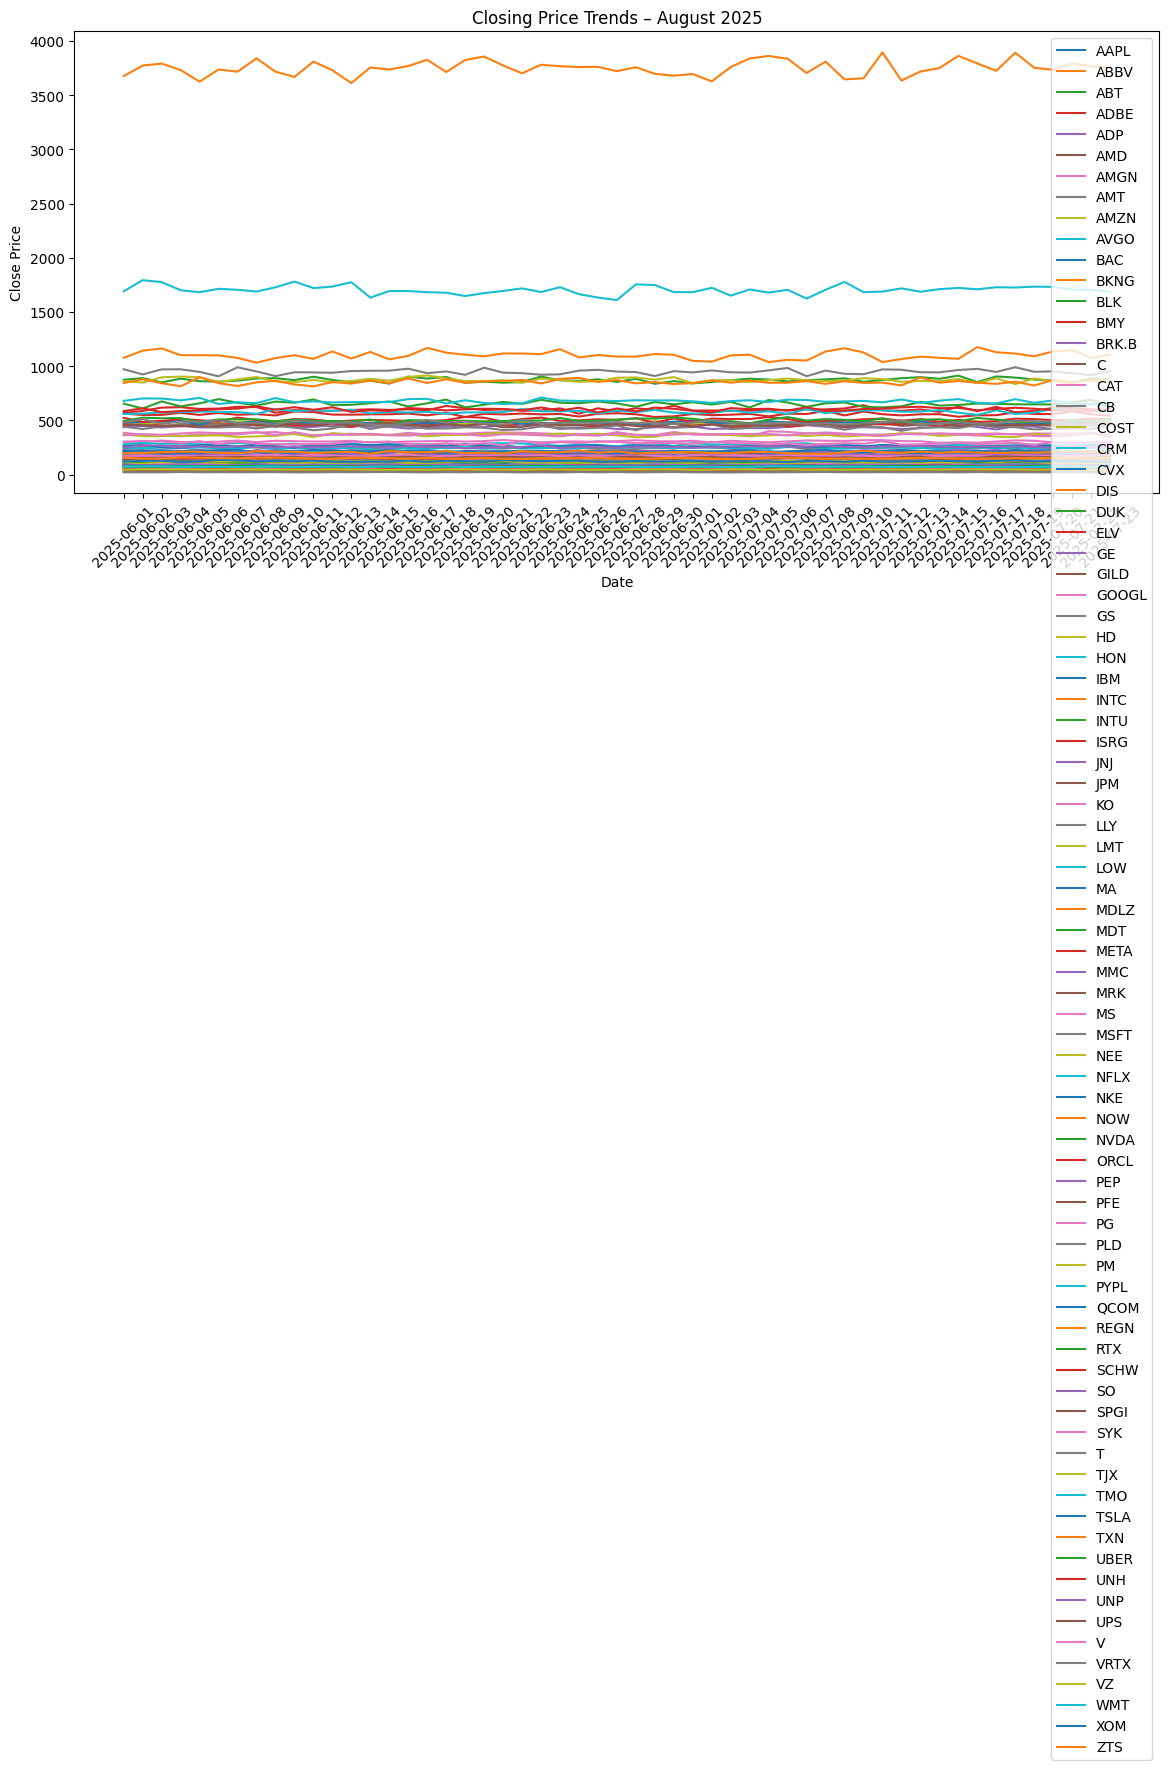

In [12]:
plt.figure(figsize=(14, 6))
for ticker in df['Ticker'].unique():
    ticker_data = df[df['Ticker'] == ticker]
    plt.plot(ticker_data['Date'], ticker_data['Close Price'], label=ticker)
plt.title("Closing Price Trends – August 2025")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

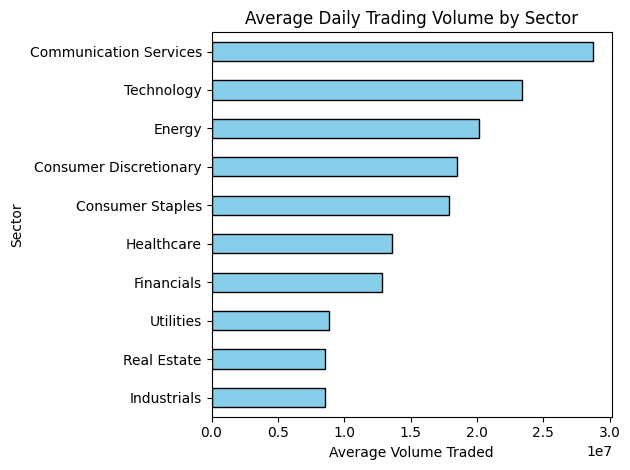

In [13]:
sector_volume = df.groupby("Sector")["Volume Traded"].mean().sort_values()
sector_volume.plot(kind="barh", color="skyblue", edgecolor="black")
plt.title("Average Daily Trading Volume by Sector")
plt.xlabel("Average Volume Traded")
plt.ylabel("Sector")
plt.tight_layout()
plt.show()

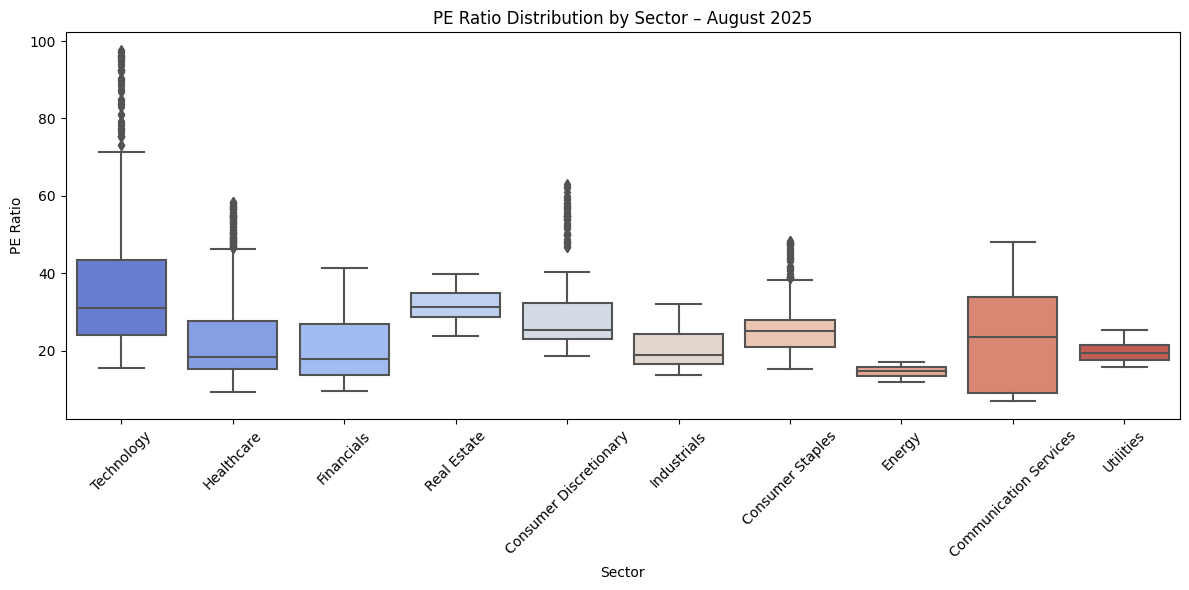

In [14]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Sector", y="PE Ratio", palette="coolwarm")
plt.title("PE Ratio Distribution by Sector – August 2025")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

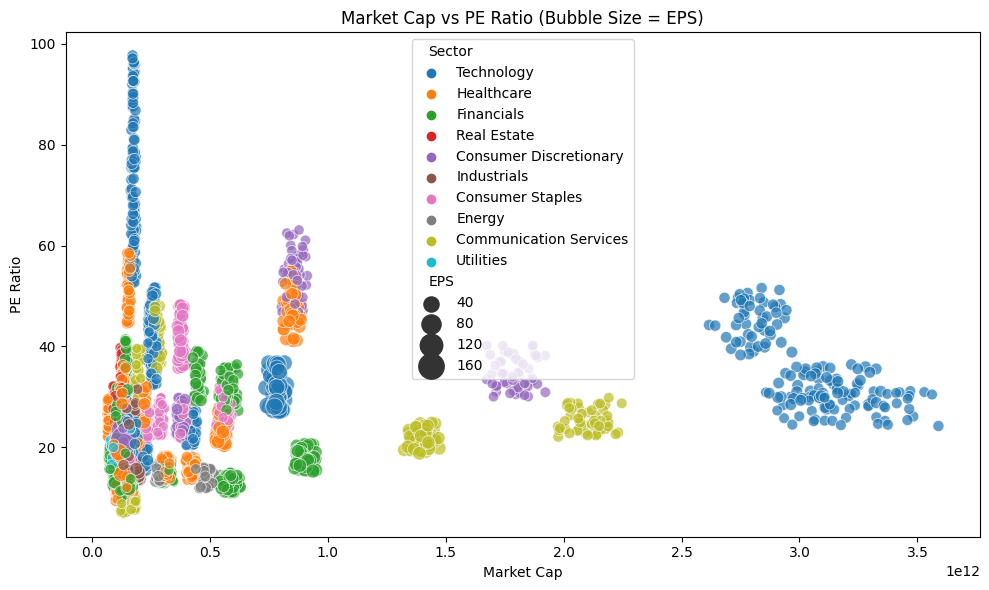

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Market Cap",
    y="PE Ratio",
    size="EPS",
    hue="Sector",
    alpha=0.7,
    sizes=(50, 400)
)
plt.title("Market Cap vs PE Ratio (Bubble Size = EPS)")
plt.xlabel("Market Cap")
plt.ylabel("PE Ratio")
plt.tight_layout()
plt.show()

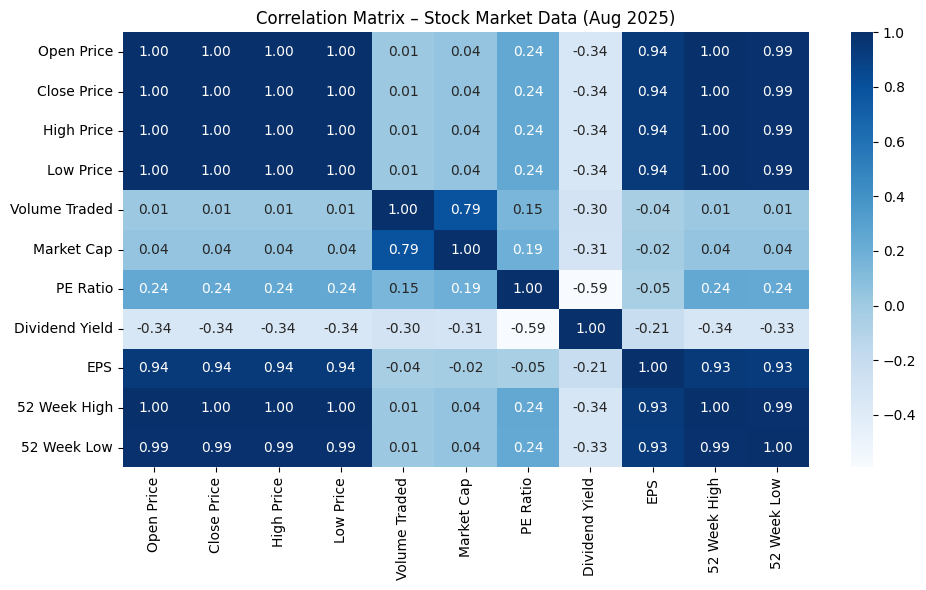

In [16]:
plt.figure(figsize=(10, 6))
numeric_cols = ["Open Price", "Close Price", "High Price", "Low Price", 
                "Volume Traded", "Market Cap", "PE Ratio", 
                "Dividend Yield", "EPS", "52 Week High", "52 Week Low"]
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues")
plt.title("Correlation Matrix – Stock Market Data (Aug 2025)")
plt.tight_layout()
plt.show()

## Predictive modeling

In [17]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
try:
    from xgboost import XGBClassifier
    xgb_available = True
except Exception:
    xgb_available = False

In [18]:
# Ensure Date is datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])
df['day'] = df['Date'].dt.day
df['weekday'] = df['Date'].dt.weekday
df['is_month_start'] = df['Date'].dt.is_month_start.astype(int)


In [19]:
expected_cols = ['Date', 'Ticker', 'Open Price', 'Close Price', 'High Price',
                 'Low Price', 'Volume Traded', 'Market Cap', 'PE Ratio',
                 'Dividend Yield', 'EPS', '52 Week High', '52 Week Low', 'Sector']
missing = [c for c in expected_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)
df['prev_close'] = df.groupby('Ticker')['Close Price'].shift(1)
df['prev_volume'] = df.groupby('Ticker')['Volume Traded'].shift(1)
df['ma_3'] = df.groupby('Ticker')['Close Price'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())
df['daily_return'] = (df['Close Price'] - df['Open Price']) / df['Open Price']
df['range_pct'] = (df['High Price'] - df['Low Price']) / df['Low Price'].replace(0, np.nan)
df['day'] = df['Date'].dt.day
df['weekday'] = df['Date'].dt.weekday
df['is_month_start'] = df['Date'].dt.is_month_start.astype(int)
df['Target'] = (df['Close Price'] > df['prev_close']).astype(int)
df = df.dropna(subset=['prev_close']).reset_index(drop=True)

feature_cols = [
    'Open Price', 'High Price', 'Low Price', 'Close Price', 'Volume Traded',
    'Market Cap', 'PE Ratio', 'Dividend Yield', 'EPS', '52 Week High', '52 Week Low',
    'prev_close', 'prev_volume', 'ma_3', 'daily_return', 'range_pct',
    'day', 'weekday', 'is_month_start',
    'Ticker', 'Sector'
]

X = df[feature_cols].copy()
y = df['Target'].copy()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())
le_ticker = LabelEncoder()
le_sector = LabelEncoder()
X['Ticker'] = le_ticker.fit_transform(X['Ticker'])
X['Sector'] = le_sector.fit_transform(X['Sector'].astype(str))
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)



=== LogisticRegression ===
Test Accuracy: 72.10%
Precision: 71.56% | Recall: 73.89% | F1: 72.71%
5-fold CV Accuracy (train): 71.74% (+/- 2.04%)

Classification report (test):
              precision    recall  f1-score   support

           0     0.7268    0.7028    0.7146       424
           1     0.7156    0.7389    0.7271       429

    accuracy                         0.7210       853
   macro avg     0.7212    0.7209    0.7208       853
weighted avg     0.7212    0.7210    0.7209       853



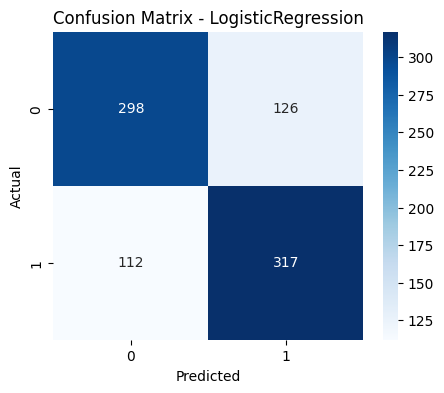


=== DecisionTree ===
Test Accuracy: 67.88%
Precision: 67.98% | Recall: 68.30% | F1: 68.14%
5-fold CV Accuracy (train): 64.70% (+/- 3.57%)

Classification report (test):
              precision    recall  f1-score   support

           0     0.6777    0.6745    0.6761       424
           1     0.6798    0.6830    0.6814       429

    accuracy                         0.6788       853
   macro avg     0.6788    0.6788    0.6788       853
weighted avg     0.6788    0.6788    0.6788       853



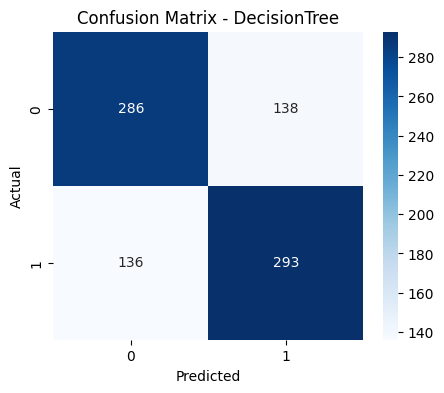


=== RandomForest ===
Test Accuracy: 78.43%
Precision: 78.29% | Recall: 79.02% | F1: 78.65%
5-fold CV Accuracy (train): 75.96% (+/- 1.96%)

Classification report (test):
              precision    recall  f1-score   support

           0     0.7857    0.7783    0.7820       424
           1     0.7829    0.7902    0.7865       429

    accuracy                         0.7843       853
   macro avg     0.7843    0.7843    0.7843       853
weighted avg     0.7843    0.7843    0.7843       853



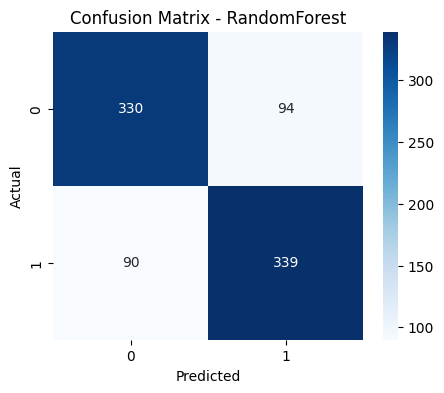


=== GradientBoosting ===
Test Accuracy: 84.17%
Precision: 85.34% | Recall: 82.75% | F1: 84.02%
5-fold CV Accuracy (train): 81.97% (+/- 1.04%)

Classification report (test):
              precision    recall  f1-score   support

           0     0.8307    0.8561    0.8432       424
           1     0.8534    0.8275    0.8402       429

    accuracy                         0.8417       853
   macro avg     0.8420    0.8418    0.8417       853
weighted avg     0.8421    0.8417    0.8417       853



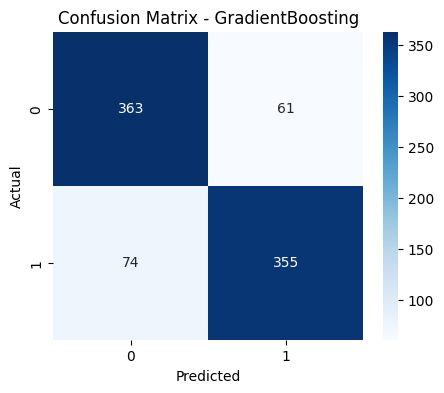


=== KNN ===
Test Accuracy: 53.93%
Precision: 54.04% | Recall: 56.18% | F1: 55.09%
5-fold CV Accuracy (train): 52.83% (+/- 0.26%)

Classification report (test):
              precision    recall  f1-score   support

           0     0.5381    0.5165    0.5271       424
           1     0.5404    0.5618    0.5509       429

    accuracy                         0.5393       853
   macro avg     0.5392    0.5391    0.5390       853
weighted avg     0.5392    0.5393    0.5390       853



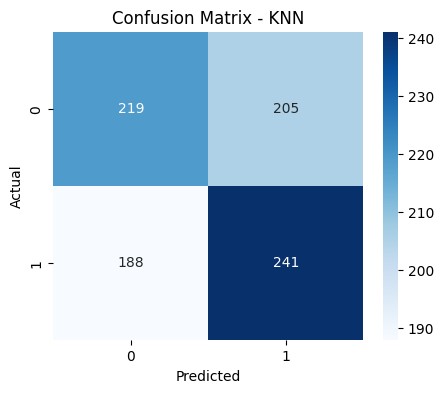


=== NaiveBayes ===
Test Accuracy: 57.33%
Precision: 56.05% | Recall: 70.16% | F1: 62.32%
5-fold CV Accuracy (train): 56.08% (+/- 3.42%)

Classification report (test):
              precision    recall  f1-score   support

           0     0.5949    0.4434    0.5081       424
           1     0.5605    0.7016    0.6232       429

    accuracy                         0.5733       853
   macro avg     0.5777    0.5725    0.5656       853
weighted avg     0.5776    0.5733    0.5660       853



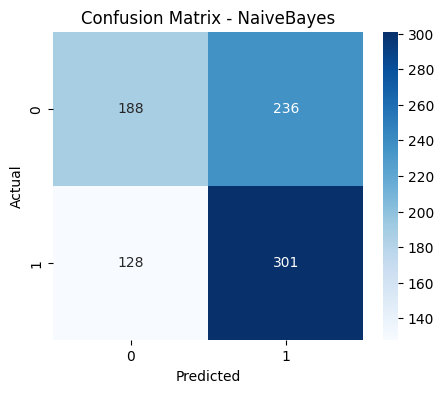


=== SVM ===
Test Accuracy: 61.43%
Precision: 61.96% | Recall: 60.37% | F1: 61.16%
5-fold CV Accuracy (train): 60.57% (+/- 1.52%)

Classification report (test):
              precision    recall  f1-score   support

           0     0.6092    0.6250    0.6170       424
           1     0.6196    0.6037    0.6116       429

    accuracy                         0.6143       853
   macro avg     0.6144    0.6144    0.6143       853
weighted avg     0.6144    0.6143    0.6143       853



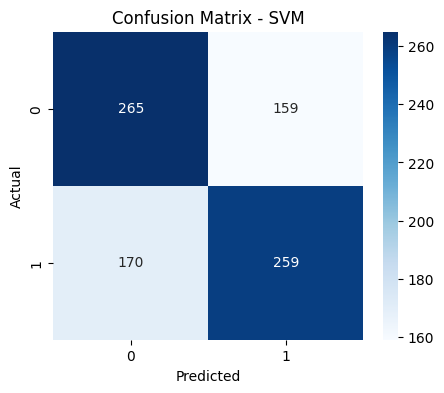


=== XGBoost ===
Test Accuracy: 88.39%
Precision: 89.86% | Recall: 86.71% | F1: 88.26%
5-fold CV Accuracy (train): 85.19% (+/- 1.81%)

Classification report (test):
              precision    recall  f1-score   support

           0     0.8702    0.9009    0.8853       424
           1     0.8986    0.8671    0.8826       429

    accuracy                         0.8839       853
   macro avg     0.8844    0.8840    0.8839       853
weighted avg     0.8844    0.8839    0.8839       853



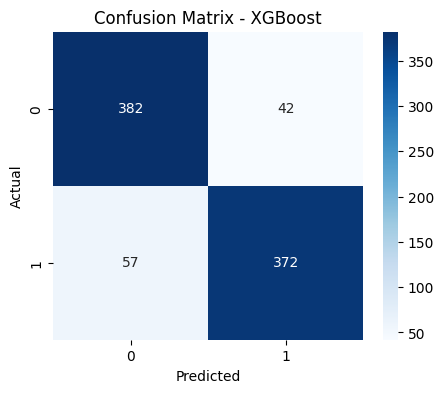


Model comparison (test metrics):
                model accuracy precision  recall      f1 cv_mean_acc
7             XGBoost   88.39%    89.86%  86.71%  88.26%      85.19%
3    GradientBoosting   84.17%    85.34%  82.75%  84.02%      81.97%
2        RandomForest   78.43%    78.29%  79.02%  78.65%      75.96%
0  LogisticRegression    72.1%    71.56%  73.89%  72.71%      71.74%
1        DecisionTree   67.88%    67.98%   68.3%  68.14%       64.7%
6                 SVM   61.43%    61.96%  60.37%  61.16%      60.57%
5          NaiveBayes   57.33%    56.05%  70.16%  62.32%      56.08%
4                 KNN   53.93%    54.04%  56.18%  55.09%      52.83%


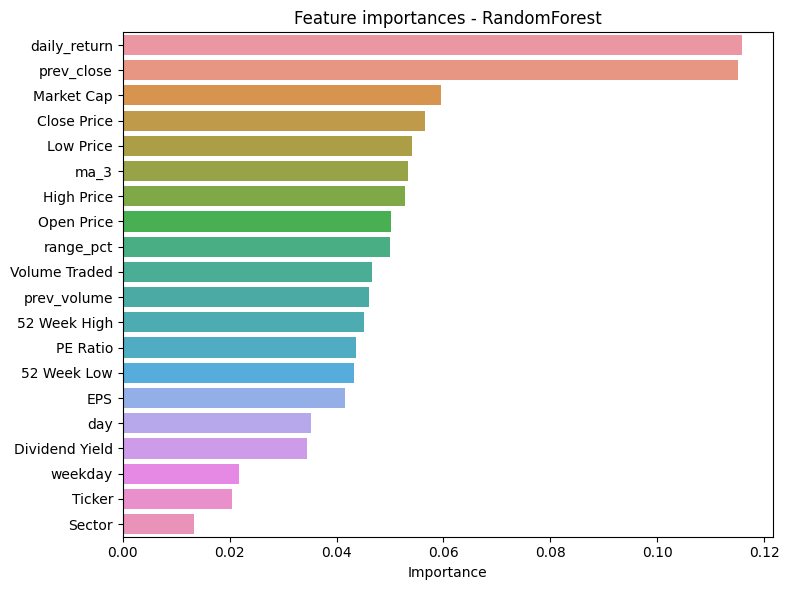

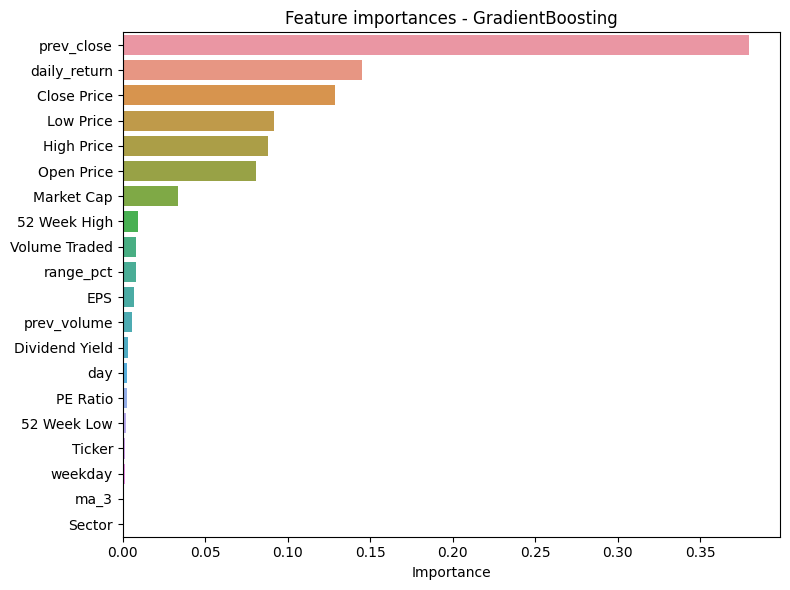

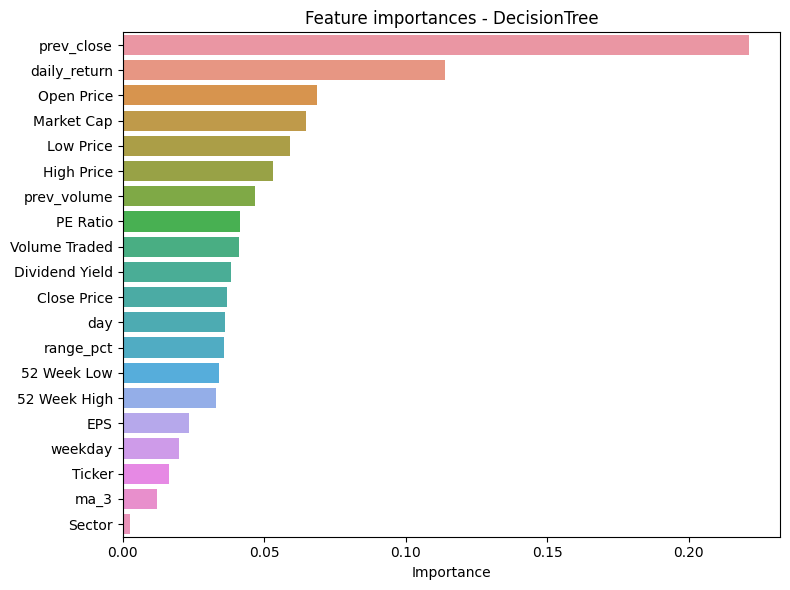

In [20]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "NaiveBayes": GaussianNB(),
    "SVM": SVC(probability=True, random_state=42)
}
if xgb_available:
    models["XGBoost"] = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring='accuracy')
    results.append({
        'model': name,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'cv_mean_acc': cv_scores.mean()
    })
    print(f"\n=== {name} ===")
    print(f"Test Accuracy: {acc*100:.2f}%")
    print(f"Precision: {prec*100:.2f}% | Recall: {rec*100:.2f}% | F1: {f1*100:.2f}%")
    print(f"5-fold CV Accuracy (train): {cv_scores.mean()*100:.2f}% (+/- {cv_scores.std()*100:.2f}%)")
    print("\nClassification report (test):")
    print(classification_report(y_test, y_pred, digits=4))
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
res_df = pd.DataFrame(results).sort_values('accuracy', ascending=False)
res_df_display = res_df.copy()
for col in ['accuracy', 'precision', 'recall', 'f1', 'cv_mean_acc']:
    res_df_display[col] = (res_df_display[col] * 100).round(2).astype(str) + '%'
print("\nModel comparison (test metrics):")
print(res_df_display[['model','accuracy','precision','recall','f1','cv_mean_acc']])
for tree_model_name in ['RandomForest', 'GradientBoosting', 'DecisionTree']:
    if tree_model_name in models:
        m = models[tree_model_name]
        if hasattr(m, 'feature_importances_'):
            fi = pd.Series(m.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(20)
            plt.figure(figsize=(8,6))
            sns.barplot(x=fi.values, y=fi.index)
            plt.title(f'Feature importances - {tree_model_name}')
            plt.xlabel('Importance')
            plt.tight_layout()
            plt.show()